<a href="https://colab.research.google.com/github/luizby20/Practica-2/blob/main/practica4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

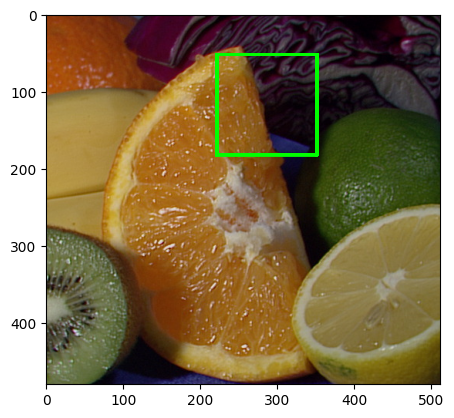

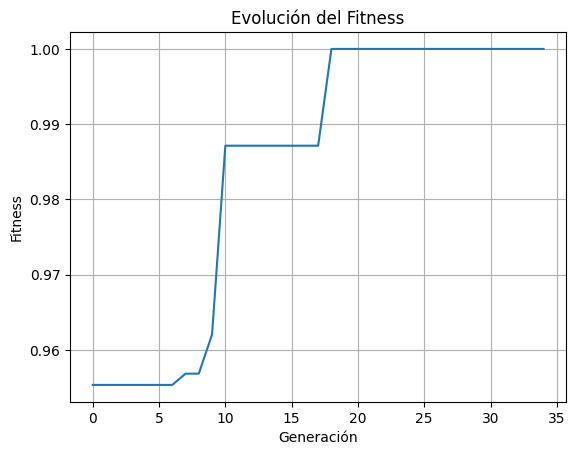

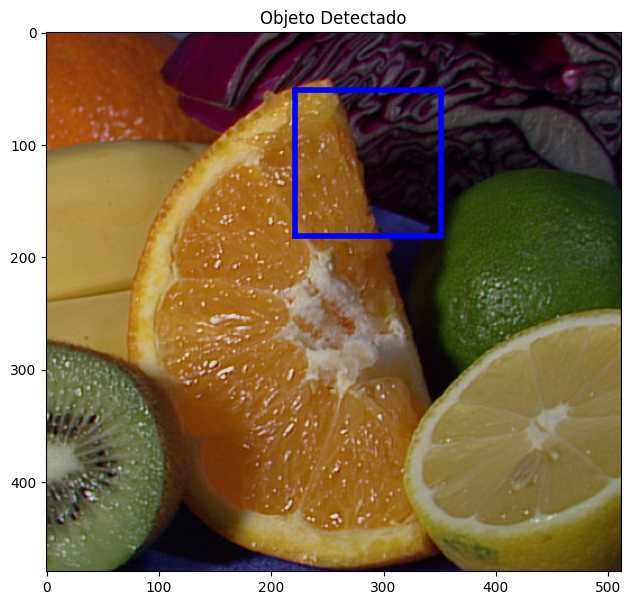

In [ ]:
!wget -nc https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg

import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython import display
import imageio
import os

# ---------------------------------
# CORRELACIÓN CRUZADA NORMALIZADA
# ---------------------------------

def NCC(img, temp, x, y):

    H = temp.shape[0]
    W = temp.shape[1]

    sum_img = 0.0
    sum_temp = 0.0
    sum_2 = 0.0

    for i in range(W):
        for j in range(H):

            sum_img += float(img[int(y)+j, int(x)+i]) ** 2
            sum_temp += float(temp[j, i]) ** 2
            sum_2 += float(img[int(y)+j, int(x)+i]) * float(temp[j, i])

    val = sum_2 / (np.sqrt(float(sum_img)) * np.sqrt(float(sum_temp)))

    return val


# ---------------------------------
# EVOLUCIÓN DIFERENCIAL
# ---------------------------------

def DE(img, temp, animacion):

    n_Gen = 35
    n_Pop = 35
    dim = 2

    F = 0.7
    Cr = 0.9

    img_g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    temp_g = cv2.cvtColor(temp, cv2.COLOR_BGR2GRAY)

    img_H = img_g.shape[0]
    img_W = img_g.shape[1]

    temp_H = temp_g.shape[0]
    temp_W = temp_g.shape[1]

    lb = np.array([1, 1])
    ub = np.array([img_W-temp_W, img_H-temp_H])

    x = np.zeros((dim, n_Pop))
    fitness = -1 * np.ones(n_Pop)

    # Inicialización
    for i in range(n_Pop):

        x[0, i] = np.random.randint(lb[0], ub[0])
        x[1, i] = np.random.randint(lb[1], ub[1])

        fitness[i] = NCC(img_g, temp_g, int(x[0, i]), int(x[1, i]))

    best_plot = np.zeros(n_Gen)
    frames = []

    # Evolución
    for n in range(n_Gen):

        if animacion:

            img_2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.clf()
            display.display(plt.gcf())
            display.clear_output(wait=True)

            plt.imshow(img_2)

            for i in range(n_Pop):

                plt.plot([x[0, i], x[0, i] + temp_W],
                         [x[1, i], x[1, i]],
                         color=(0,1,0), linewidth=2)

                plt.plot([x[0, i], x[0, i]],
                         [x[1, i], x[1, i] + temp_H],
                         color=(0,1,0), linewidth=2)

                plt.plot([x[0, i] + temp_W, x[0, i] + temp_W],
                         [x[1, i], x[1, i] + temp_H],
                         color=(0,1,0), linewidth=2)

                plt.plot([x[0, i], x[0, i] + temp_W],
                         [x[1, i] + temp_H, x[1, i] + temp_H],
                         color=(0,1,0), linewidth=2)

            plt.savefig(f'frame_{n}.png')
            frames.append(imageio.v2.imread(f'frame_{n}.png'))

            os.remove(f'frame_{n}.png')

            plt.show(block=False)
            plt.pause(.05)

        # Evolución Diferencial
        for i in range(n_Pop):

            # Mutación
            r1 = i
            while r1 == i:
                r1 = np.random.randint(n_Pop)

            r2 = r1
            while r2 == r1 or r2 == i:
                r2 = np.random.randint(n_Pop)

            r3 = r2
            while r3 == r2 or r3 == r1 or r3 == i:
                r3 = np.random.randint(n_Pop)

            v = x[:, r1] + F * (x[:, r2] - x[:, r3])

            # Recombinación
            u = np.zeros(dim)

            for j in range(dim):

                r = np.random.rand()

                if r <= Cr:
                    u[j] = v[j]
                else:
                    u[j] = x[j, i]

                # Límites
                if u[j] < lb[j] or u[j] > ub[j]:
                    u[j] = lb[j] + (ub[j] - lb[j]) * np.random.rand()

            # Selección
            fitness_u = NCC(img_g, temp_g, int(u[0]), int(u[1]))

            if fitness_u > fitness[i]:

                x[:, i] = u.copy()
                fitness[i] = fitness_u

        best_plot[n] = np.max(fitness)

    ind = np.argmax(fitness)
    p = x[:, ind]

    # Gráfica fitness
    plt.figure()
    plt.plot(best_plot)
    plt.xlabel("Generación")
    plt.ylabel("Fitness")
    plt.title("Evolución del Fitness")
    plt.grid()
    plt.show()

    # Guardar GIF
    if animacion:
        imageio.mimsave('animacion.gif', frames, fps=10)

    return p


# ---------------------------------
# CARGA DE IMAGEN
# ---------------------------------

animacion = 1

img = cv2.imread('fruits.jpg')

# Recorte de una fruta como plantilla
temp = img[50:180, 220:350]

# ---------------------------------
# EJECUCIÓN
# ---------------------------------

p = DE(img, temp, animacion)

img_H = img.shape[0]
img_W = img.shape[1]

temp_H = temp.shape[0]
temp_W = temp.shape[1]

xp = p[0]
yp = p[1]

# ---------------------------------
# RESULTADO FINAL
# ---------------------------------

img_2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,7))
plt.imshow(img_2)

# Rectángulo azul
plt.plot([xp, xp+temp_W], [yp, yp], 'b', linewidth=4)
plt.plot([xp, xp], [yp, yp+temp_H], 'b', linewidth=4)
plt.plot([xp+temp_W, xp+temp_W], [yp, yp+temp_H], 'b', linewidth=4)
plt.plot([xp, xp+temp_W], [yp+temp_H, yp+temp_H], 'b', linewidth=4)

plt.title("Objeto Detectado")
plt.show()